In [2]:
from google.colab import files
import pandas as pd

print("📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment")

uploaded = files.upload()

# Tạo biến chứa dataframe
df_jpm = df_bac = df_wfc = df_fed = df_spx = df_sentiment = None

for filename in uploaded.keys():

    print("Đã tải:", filename)

    if "JPM" in filename or "JP Morgan" in filename:
        df_jpm = pd.read_excel(filename)

    elif "BAC" in filename or "Bank of America" in filename:
        df_bac = pd.read_excel(filename)

    elif "WFC" in filename or "Wells Fargo " in filename:
        df_wfc = pd.read_excel(filename)

    elif "Lãi suất FED" in filename:
        df_fed = pd.read_excel(filename)

    elif "SPX500" in filename:
        df_spx = pd.read_excel(filename)

    elif "Sentiment" in filename:
        df_sentiment = pd.read_excel(filename)

# Kiểm tra đủ file chưa
required = {
    "JPM": df_jpm,
    "BAC": df_bac,
    "WFC": df_wfc,
    "FED": df_fed,
    "SPX": df_spx,
    "Sentiment": df_sentiment
}

missing = [name for name, df in required.items() if df is None]

if missing:
    print("\n❌ Thiếu file:", missing)
else:
    print("\n✅ Đã load đủ 6 file!")


📂 Hãy upload 6 file Excel: JPM, BAC, WFC, FED, SPX, sentiment


Saving SPX500.csv.xlsx to SPX500.csv (1).xlsx
Saving Sentiment.xlsx to Sentiment (1).xlsx
Saving JP Morgan.xlsx to JP Morgan (1).xlsx
Saving Lãi suất FED.xlsx to Lãi suất FED (1).xlsx
Saving Wells Fargo.xlsx to Wells Fargo (1).xlsx
Saving Bank of America.xlsx to Bank of America (1).xlsx
Đã tải: SPX500.csv (1).xlsx
Đã tải: Sentiment (1).xlsx
Đã tải: JP Morgan (1).xlsx
Đã tải: Lãi suất FED (1).xlsx
Đã tải: Wells Fargo (1).xlsx
Đã tải: Bank of America (1).xlsx

✅ Đã load đủ 6 file!


In [3]:


print("🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...")

# --- 1. HÀM CHUẨN HÓA NGÀY THÁNG ---
def clean_date(df):
    # Xóa khoảng trắng thừa ở tên cột
    df.columns = df.columns.str.strip()
    # Tìm cột Date
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date']).dt.normalize() # Xóa giờ phút giây
    return df

# --- 2. ĐỌC DỮ LIỆU TỪ FILE ---
try:
    # A. Dữ liệu Vĩ mô & Tin tức
    fed = pd.read_excel('Lãi suất FED (1).xlsx')
    sentiment = pd.read_excel('Sentiment (1).xlsx')
    spx = pd.read_excel('SPX500.csv (1).xlsx')

    # B. Dữ liệu 3 Cổ phiếu
    jpm = pd.read_excel('JP Morgan (1).xlsx')
    wfc = pd.read_excel('Wells Fargo (1).xlsx')
    bac = pd.read_excel('Bank of America (1).xlsx')

    print("   -> Đã đọc xong 6 file Excel.")

except FileNotFoundError:
    print("❌ LỖI: Không tìm thấy file. Hãy đảm bảo bạn đã upload đủ 6 file và đúng tên.")
    # Dừng chương trình nếu thiếu file
    raise

# --- 3. LÀM SẠCH CHI TIẾT ---

# A. Chuẩn hóa ngày tháng cho tất cả
fed = clean_date(fed)
sentiment = clean_date(sentiment)
spx = clean_date(spx)
jpm = clean_date(jpm)
wfc = clean_date(wfc)
bac = clean_date(bac)

# B. Xử lý file Lãi suất FED (Thường hay bị lỗi định dạng text)
# Ép cột EFFR sang số, nếu lỗi biến thành NaN
fed['EFFR'] = pd.to_numeric(fed['EFFR'], errors='coerce')
# Sắp xếp theo ngày
fed = fed.sort_values('Date')
# Lấp đầy lãi suất (Forward Fill - Lãi suất hôm nay = hôm qua nếu ko có dữ liệu)
fed['EFFR'] = fed['EFFR'].ffill()

# C. Đổi tên cột để tránh trùng lặp khi gộp
# Chỉ giữ lại cột Date, Close và Volume (nếu cần)
spx = spx[['Date', 'Close']].rename(columns={'Close': 'SPX_Close'})

jpm = jpm[['Date', 'Close']].rename(columns={'Close': 'JPM_Close'})
wfc = wfc[['Date', 'Close']].rename(columns={'Close': 'WFC_Close'})
bac = bac[['Date', 'Close']].rename(columns={'Close': 'BAC_Close'})

# --- 4. HỢP NHẤT DỮ LIỆU (MERGE) ---
print("🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...")

# Lấy SPX làm khung xương (Backbone) vì chỉ số thị trường có lịch giao dịch chuẩn nhất
master_df = spx

# Gộp lần lượt các cổ phiếu vào (Left Join theo ngày)
master_df = master_df.merge(jpm, on='Date', how='left')
master_df = master_df.merge(wfc, on='Date', how='left')
master_df = master_df.merge(bac, on='Date', how='left')

# Gộp thông tin vĩ mô (FED) và Tin tức (Sentiment)
master_df = master_df.merge(fed[['Date', 'EFFR']], on='Date', how='left')
master_df = master_df.merge(sentiment, on='Date', how='left')

# --- 5. XỬ LÝ SAU KHI GỘP ---
# A. Lấp đầy dữ liệu FED cho những ngày cuối tuần/nghỉ lễ nếu bị hổng
master_df['EFFR'] = master_df['EFFR'].ffill()

# B. Xử lý Sentiment bị thiếu (NaN -> 0)
# Tìm các cột sentiment tự động
sent_cols = [c for c in master_df.columns if 'sentiment' in c or 'news_count' in c]
master_df[sent_cols] = master_df[sent_cols].fillna(0)

# C. Loại bỏ những ngày không giao dịch (Cả 3 cổ phiếu đều NaN)
stock_cols = ['JPM_Close', 'WFC_Close', 'BAC_Close']
master_df = master_df.dropna(subset=stock_cols, how='all').reset_index(drop=True)

# Kiểm tra kết quả
print(f"✅ HOÀN TẤT! Master DataFrame có kích thước: {master_df.shape}")
print("   -> Sẵn sàng cho bước dự báo.")
print("-" * 60)
print(master_df.head())

🟢 BƯỚC 1: ĐANG ĐỌC VÀ LÀM SẠCH DỮ LIỆU THÔ...
   -> Đã đọc xong 6 file Excel.
🟡 BƯỚC 2: ĐANG GỘP DỮ LIỆU (MERGE)...
✅ HOÀN TẤT! Master DataFrame có kích thước: (1977, 12)
   -> Sẵn sàng cho bước dự báo.
------------------------------------------------------------
        Date    SPX_Close  JPM_Close  WFC_Close  BAC_Close  EFFR  \
0 2018-01-02  2695.810059     107.95      61.09      29.90  1.42   
1 2018-01-03  2713.060059     108.06      61.56      29.80  1.42   
2 2018-01-04  2723.989990     109.04      62.33      30.19  1.42   
3 2018-01-05  2743.149902     108.34      62.75      30.33  1.42   
4 2018-01-08  2747.709961     108.50      62.04      30.12  1.91   

   BAC_news_count  JPM_news_count  WFC_news_count  BAC_avg_sentiment  \
0             0.0             0.0             0.0                0.0   
1             0.0             0.0             0.0                0.0   
2             0.0             0.0             0.0                0.0   
3             0.0             0.0      

In [8]:
import pandas as pd
import numpy as np

# --- HÀM GỘP DỮ LIỆU ---
def merge_stock_data(df_stock, df_fed, df_spx, df_sentiment, ticker):
    # Tạo bản sao
    stock = df_stock.copy()
    fed = df_fed.copy()
    spx = df_spx.copy()
    sent = df_sentiment.copy()

    # 1. Chuẩn hóa ngày tháng
    stock['Date'] = pd.to_datetime(stock['Date']).dt.normalize()
    fed['Date'] = pd.to_datetime(fed['Date']).dt.normalize()
    spx['Date'] = pd.to_datetime(spx['Date']).dt.normalize()
    sent['Date'] = pd.to_datetime(sent['Date']).dt.normalize()

    # 2. Đổi tên cột SPX
    if 'Close' in spx.columns:
        spx = spx.rename(columns={'Close': 'SPX_Close'})
    spx_clean = spx[['Date', 'SPX_Close']] if 'SPX_Close' in spx.columns else spx

    # 3. Merge
    df_merge = stock.merge(fed, on='Date', how='left')
    df_merge = df_merge.merge(spx_clean, on='Date', how='left')

    # 4. Merge Sentiment
    sent_col = f'{ticker}_avg_sentiment'
    if sent_col in sent.columns:
        df_merge = df_merge.merge(sent[['Date', sent_col]], on='Date', how='left')
    else:
        df_merge[sent_col] = 0

    # 5. Fill NaN
    for col in df_merge.columns:
        if col != 'Date':
            df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')
            df_merge[col] = df_merge[col].ffill().bfill()
            df_merge[col] = df_merge[col].fillna(0)

    return df_merge.sort_values('Date').reset_index(drop=True)

# --- CHẠY TẠO BIẾN ---
try:
    print("⏳ Đang tạo lại dữ liệu df_jpm_final, df_bac_final, df_wfc_final...")

    # Giả định bạn đã upload và read_excel thành df_jpm, df_fed... ở các bước đầu tiên
    df_jpm_final = merge_stock_data(df_jpm, df_fed, df_spx, df_sentiment, 'JPM')
    df_bac_final = merge_stock_data(df_bac, df_fed, df_spx, df_sentiment, 'BAC')
    df_wfc_final = merge_stock_data(df_wfc, df_fed, df_spx, df_sentiment, 'WFC')

    print("✅ Đã tạo xong dữ liệu! Giờ bạn có thể chạy code BDLM.")

except NameError:
    print("❌ LỖI: Bạn chưa đọc file Excel ban đầu (df_jpm, df_fed...).")
    print("👉 Hãy quay lại bước 'Upload file' và chạy lại lệnh pd.read_excel().")

⏳ Đang tạo lại dữ liệu df_jpm_final, df_bac_final, df_wfc_final...
✅ Đã tạo xong dữ liệu! Giờ bạn có thể chạy code BDLM.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pydlm import dlm, trend, dynamic
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings

# Tắt cảnh báo
warnings.filterwarnings("ignore")

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...



🟢 --- [BACKTEST] BDLM WALK-FORWARD: JPM ---
   -> Đang chạy bộ lọc Kalman (Training)...


INFO:pydlm:Forward filtering completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...


   -> Đang trích xuất dữ liệu dự báo (Prior)...
✅ KẾT QUẢ BACKTEST THỰC TẾ: RMSE=2.07 | MAPE=0.91%

🔮 --- [FORECAST] DỰ BÁO 90 NGÀY TƯƠNG LAI (BDLM): JPM ---
   -> Đang tổng hợp dữ liệu và dự báo...


INFO:pydlm:Forward filtering completed.


🎨 Đang vẽ biểu đồ BDLM toàn cảnh cho JPM...


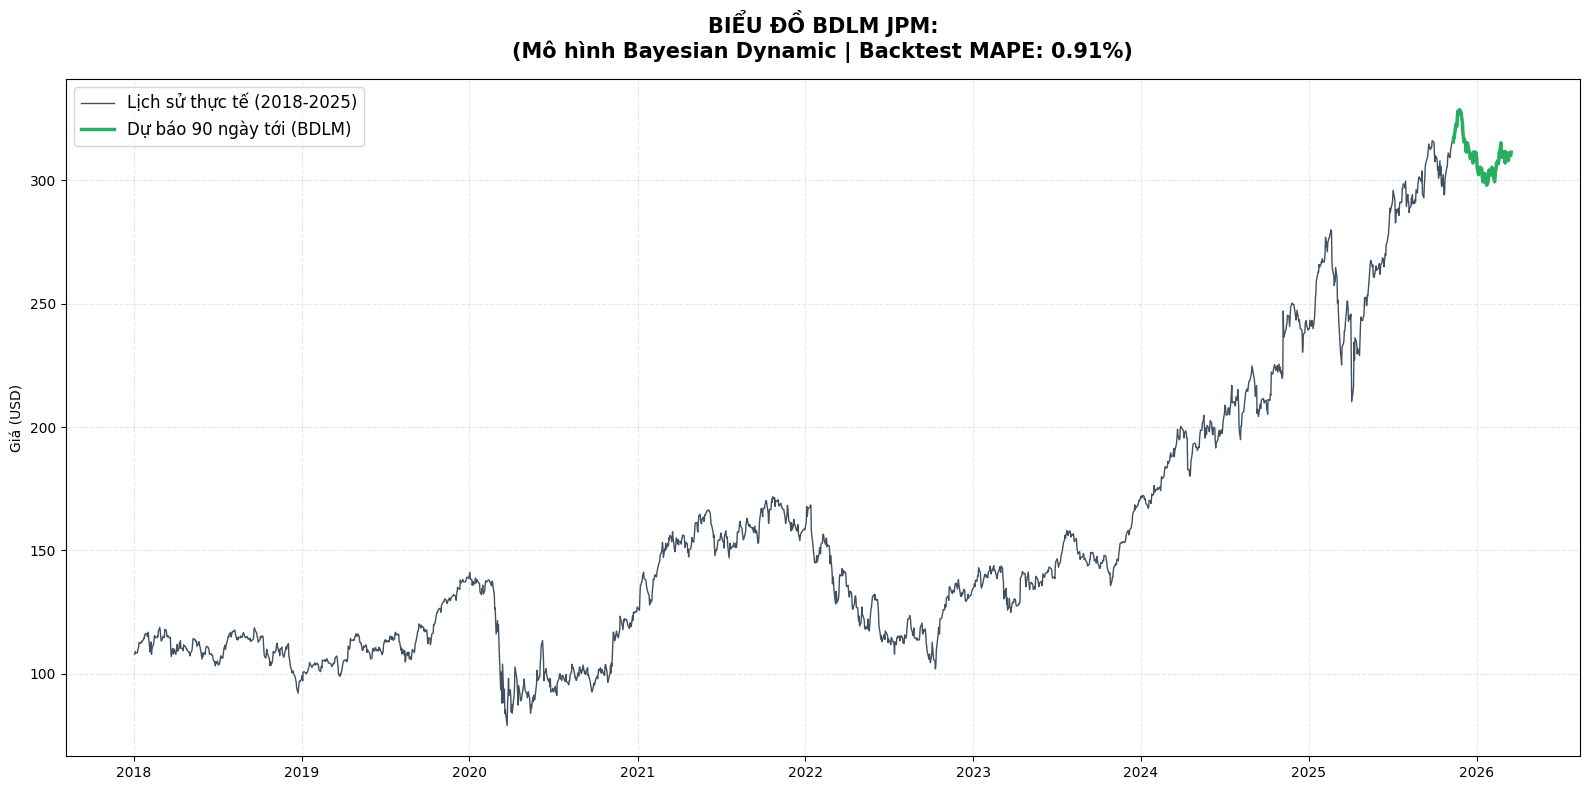

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...



🟢 --- [BACKTEST] BDLM WALK-FORWARD: BAC ---
   -> Đang chạy bộ lọc Kalman (Training)...


INFO:pydlm:Forward filtering completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...


   -> Đang trích xuất dữ liệu dự báo (Prior)...
✅ KẾT QUẢ BACKTEST THỰC TẾ: RMSE=0.52 | MAPE=1.08%

🔮 --- [FORECAST] DỰ BÁO 90 NGÀY TƯƠNG LAI (BDLM): BAC ---
   -> Đang tổng hợp dữ liệu và dự báo...


INFO:pydlm:Forward filtering completed.


🎨 Đang vẽ biểu đồ BDLM toàn cảnh cho BAC...


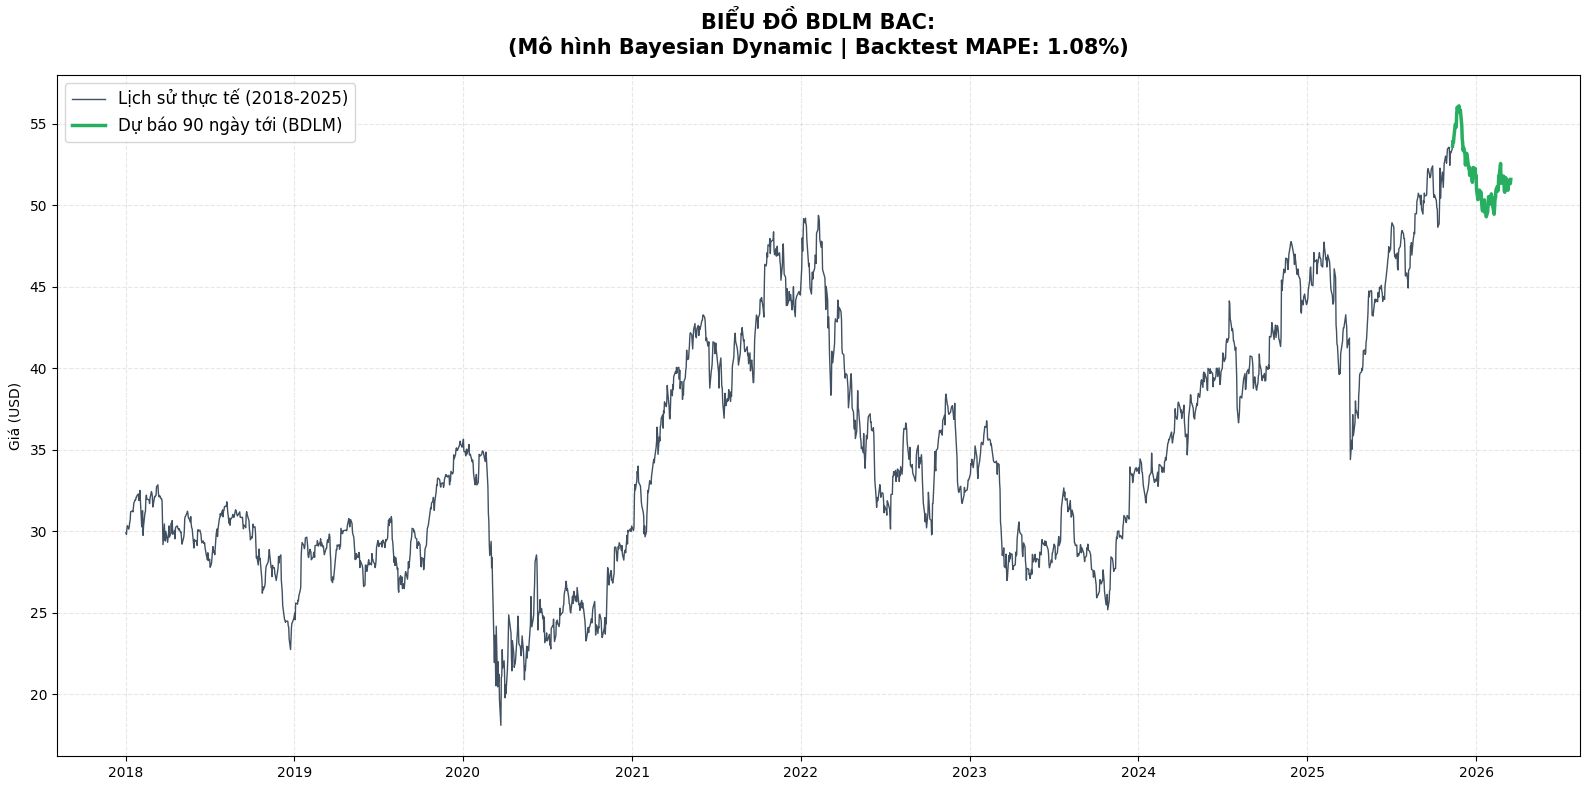

INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...



🟢 --- [BACKTEST] BDLM WALK-FORWARD: WFC ---
   -> Đang chạy bộ lọc Kalman (Training)...


INFO:pydlm:Forward filtering completed.
INFO:pydlm:Initializing models...
INFO:pydlm:Initialization finished.
INFO:pydlm:Starting forward filtering...


   -> Đang trích xuất dữ liệu dự báo (Prior)...
✅ KẾT QUẢ BACKTEST THỰC TẾ: RMSE=242.05 | MAPE=8.73%

🔮 --- [FORECAST] DỰ BÁO 90 NGÀY TƯƠNG LAI (BDLM): WFC ---
   -> Đang tổng hợp dữ liệu và dự báo...


INFO:pydlm:Forward filtering completed.


🎨 Đang vẽ biểu đồ BDLM toàn cảnh cho WFC...


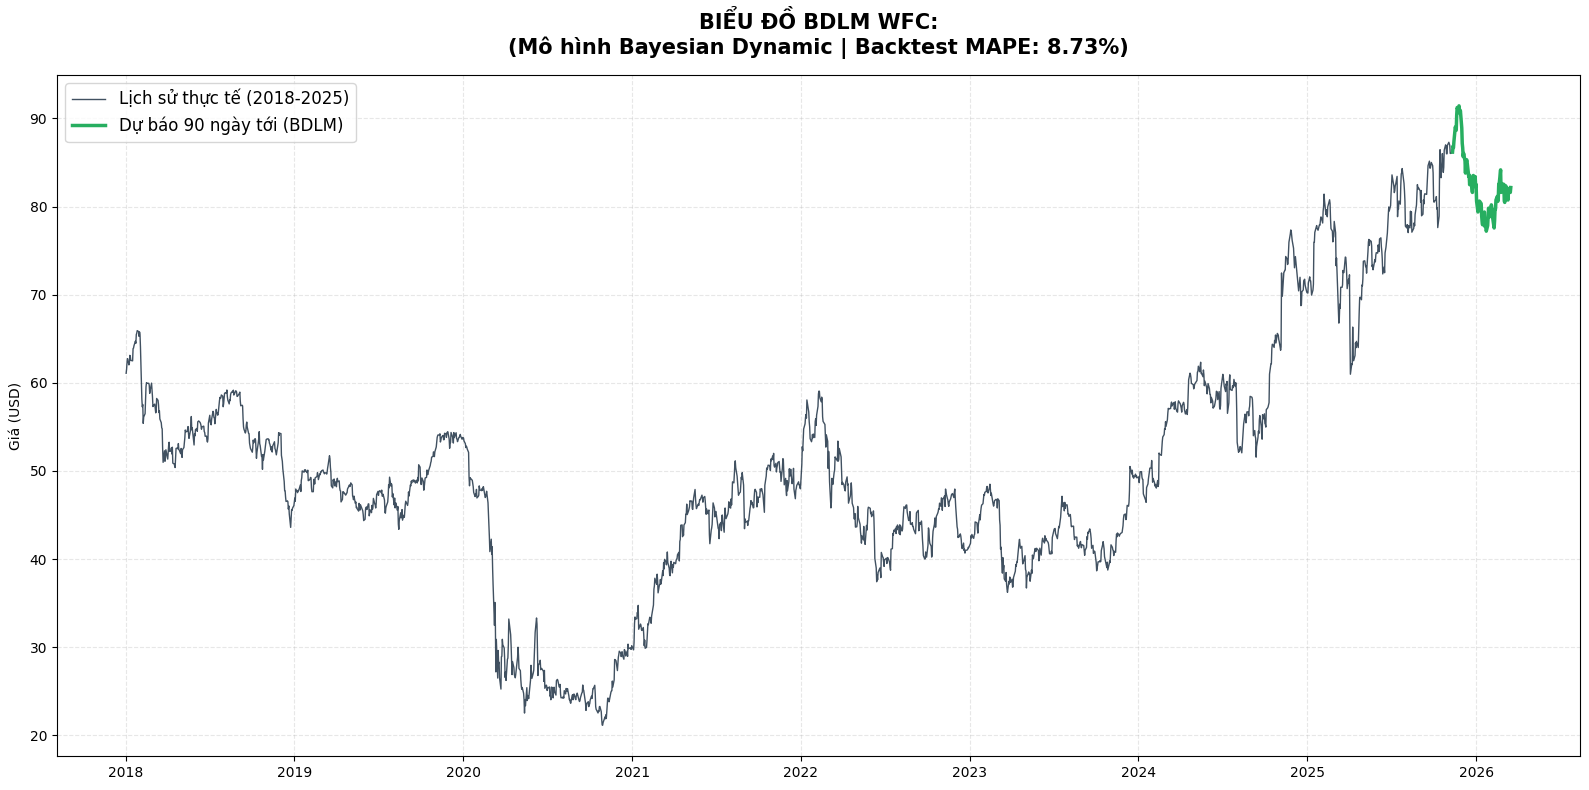

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pydlm import dlm, trend, dynamic
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. HÀM BACKTEST BDLM (ĐÃ SỬA LỖI MAPE 0%)
# ==========================================
def run_bdlm_backtest_final(df, ticker):
    print(f"\n🟢 --- [BACKTEST] BDLM WALK-FORWARD: {ticker} ---")

    # 1. Chuẩn bị dữ liệu
    data = df.copy().dropna().reset_index(drop=True)
    target_col = 'Close'
    exog_cols = ['EFFR', 'SPX_Close', f'{ticker}_avg_sentiment']

    # Chuyển về list float
    y = [float(val) for val in data[target_col].values]
    X = data[exog_cols].values.tolist()

    # 2. Xây dựng mô hình
    model = dlm(y) + \
            trend(degree=1, discount=0.95, name='local_trend') + \
            dynamic(features=X, discount=0.90, name='exog_reg')

    # 3. Chạy bộ lọc
    print("   -> Đang chạy bộ lọc Kalman (Training)...")
    model.fitForwardFilter()

    # 4. TRÍCH XUẤT DỰ BÁO TRUNG THỰC (ONE-STEP-AHEAD)
    # Thay vì dùng getMean() (là Filtered), ta dùng predictedObs (là Prior)
    # Đây là giá trị dự báo được tính TRƯỚC KHI cập nhật dữ liệu thực tế
    print("   -> Đang trích xuất dữ liệu dự báo (Prior)...")

    raw_predictions = model.result.predictedObs

    # Xử lý ma trận để lấy số thực (Scalar)
    predictions = []
    for item in raw_predictions:
        # item là numpy matrix, cần lấy giá trị đầu tiên
        if hasattr(item, 'item'):
            val = item.item()
        else:
            val = float(item)
        predictions.append(val)

    actuals = y

    # Bỏ qua 50 ngày đầu (Warm-up) để bộ lọc ổn định
    warmup = 50

    rmse = np.sqrt(mean_squared_error(actuals[warmup:], predictions[warmup:]))
    mape = mean_absolute_percentage_error(actuals[warmup:], predictions[warmup:])

    print(f"✅ KẾT QUẢ BACKTEST THỰC TẾ: RMSE={rmse:.2f} | MAPE={mape:.2%}")
    return mape

# ==========================================
# 2. HÀM DỰ BÁO TƯƠNG LAI (GIỮ NGUYÊN)
# ==========================================
def predict_future_bdlm_90days(df, ticker):
    print(f"\n🔮 --- [FORECAST] DỰ BÁO 90 NGÀY TƯƠNG LAI (BDLM): {ticker} ---")

    data = df.copy().dropna().reset_index(drop=True)
    target_col = 'Close'
    exog_cols = ['EFFR', 'SPX_Close', f'{ticker}_avg_sentiment']

    past_y = [float(x) for x in data[target_col].values]
    past_X = data[exog_cols].values.tolist()

    # Kịch bản tương lai
    days_predict = 90
    last_date = data['Date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=days_predict, freq='B')

    last_effr = data['EFFR'].iloc[-1]
    last_spx = data['SPX_Close'].iloc[-1]

    future_spx = []
    current_spx = last_spx
    np.random.seed(42)
    for _ in range(days_predict):
        shock = np.random.normal(loc=0.0003, scale=0.008)
        current_spx = current_spx * (1 + shock)
        future_spx.append(current_spx)

    future_effr = [last_effr] * days_predict
    future_sentiment = np.random.normal(0, 0.1, days_predict).tolist()

    future_X = []
    for i in range(days_predict):
        future_X.append([future_effr[i], future_spx[i], future_sentiment[i]])

    # Dự báo tương lai
    print("   -> Đang tổng hợp dữ liệu và dự báo...")
    all_y = past_y + [None] * days_predict
    all_X = past_X + future_X

    model_future = dlm(all_y) + \
                   trend(degree=1, discount=0.95, name='local_trend') + \
                   dynamic(features=all_X, discount=0.90, name='exog_reg')

    model_future.fitForwardFilter()

    # Với tương lai (None), getMean() chính là dự báo tốt nhất
    all_means_matrix = model_future.getMean()

    all_means_scalar = []
    for val in all_means_matrix:
         if hasattr(val, 'item'):
            all_means_scalar.append(val.item())
         else:
            all_means_scalar.append(float(val))

    forecast_values = all_means_scalar[-days_predict:]

    return pd.DataFrame({'Date': future_dates, 'Forecast': forecast_values})

# ==========================================
# 3. HÀM VẼ BIỂU ĐỒ PANORAMA
# ==========================================
def plot_panorama_bdlm(df_history, df_forecast, ticker, backtest_mape):
    print(f"🎨 Đang vẽ biểu đồ BDLM toàn cảnh cho {ticker}...")

    fig, ax = plt.subplots(figsize=(16, 8))

    # Vẽ lịch sử
    start_year = df_history['Date'].dt.year.min()
    end_year = df_history['Date'].dt.year.max()

    ax.plot(df_history['Date'], df_history['Close'],
            label=f'Lịch sử thực tế ({start_year}-{end_year})',
            color='#2c3e50', linewidth=1, alpha=0.9)

    # Vẽ dự báo
    ax.plot(df_forecast['Date'], df_forecast['Forecast'],
            label='Dự báo 90 ngày tới (BDLM)', color='#27ae60', linewidth=2.5)

    # Nối nét
    last_hist_date = df_history['Date'].iloc[-1]
    last_hist_price = df_history['Close'].iloc[-1]
    first_pred_date = df_forecast['Date'].iloc[0]
    first_pred_price = df_forecast['Forecast'].iloc[0]

    ax.plot([last_hist_date, first_pred_date], [last_hist_price, first_pred_price],
            color='#27ae60', linestyle='-', linewidth=2.5)

    ax.set_title(f'BIỂU ĐỒ BDLM {ticker}:\n(Mô hình Bayesian Dynamic | Backtest MAPE: {backtest_mape:.2%})',
                 fontsize=15, fontweight='bold', pad=15)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax.set_ylabel('Giá (USD)')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. CHẠY LẠI THỰC TẾ
# ==========================================
try:
    # 1. JPM
    mape_jpm_bdlm = run_bdlm_backtest_final(df_jpm_final, 'JPM')
    pred_jpm_bdlm = predict_future_bdlm_90days(df_jpm_final, 'JPM')
    plot_panorama_bdlm(df_jpm_final, pred_jpm_bdlm, 'JPM', mape_jpm_bdlm)

    # 2. BAC
    mape_bac_bdlm = run_bdlm_backtest_final(df_bac_final, 'BAC')
    pred_bac_bdlm = predict_future_bdlm_90days(df_bac_final, 'BAC')
    plot_panorama_bdlm(df_bac_final, pred_bac_bdlm, 'BAC', mape_bac_bdlm)

    # 3. WFC
    mape_wfc_bdlm = run_bdlm_backtest_final(df_wfc_final, 'WFC')
    pred_wfc_bdlm = predict_future_bdlm_90days(df_wfc_final, 'WFC')
    plot_panorama_bdlm(df_wfc_final, pred_wfc_bdlm, 'WFC', mape_wfc_bdlm)

except NameError:
    print("❌ LỖI: Không tìm thấy biến dữ liệu (df_jpm_final...).")
    print("👉 Hãy chạy lại phần Merge Data trước.")